# 0. Overview: the whole workflow on one page

mantispy does image-based profiling on AnnData. A CellProfiler run, a published profile
table or a JUMP parquet goes in. Quality-controlled profiles, hit calls, effect sizes,
mechanisms and enrichment come out, all stored on the object, so no result exists only in a
notebook variable.

Everything here is a scverse object. `adata.obs` records where a profile came from,
`adata.var` records what each feature measures (parsed from its CellProfiler name), and
`adata.uns["mantispy"]` holds the provenance and every result table. scanpy's PCA,
neighbors, clustering and embeddings work on it unchanged, and mantispy does not reimplement
them.

This page runs the workflow end to end. Each of the other tutorials covers one part of it in
depth.

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc

import mantispy as mt

## The recipe

Twelve calls on BBBC021, the field's reference benchmark. Each row links to the tutorial that
covers it.

| step | what it is for | page |
|---|---|---|
| `ds.bbbc021` | reading data; `io.read_profiles`, `io.read_jump` and, for images, `io.read_plate` are the real entry points | [1](01_from_cellprofiler_to_anndata.ipynb) |
| `pp.normalize` | put every plate on the same scale, against its own controls | [2](02_from_cells_to_profiles.ipynb) |
| `var["degenerate_scale"]` | drop features with no spread among the controls, before they dominate every distance | [3](03_trustworthy_profiles.ipynb) |
| `pp.feature_select` | drop what is redundant or unmeasurable | [3](03_trustworthy_profiles.ipynb) |
| `tl.aggregate` | cells to wells | [2](02_from_cells_to_profiles.ipynb) |
| `metrics.evaluate_correction` | check whether a correction helped | [4](04_correcting_and_evaluating.ipynb) |
| `tl.hit_calling` | which perturbations had an effect, with a p-value | [5](05_hits_and_effects.ipynb) |
| `tl.effect_size` | which features moved, and by how much | [5](05_hits_and_effects.ipynb) |
| `tl.consensus` | one signature per perturbation | [5](05_hits_and_effects.ipynb) |
| `tl.nn_moa_classify` | what does this compound do | [6](06_mechanism_of_action.ipynb) |
| `tl.enrich` | which kinds of measurement moved | [6](06_mechanism_of_action.ipynb) |
| `io.write` | everything above, in one file | [1](01_from_cellprofiler_to_anndata.ipynb) |

In [2]:
adata = mt.ds.bbbc021()

mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)

adata

/Users/tim.treis/Documents/GitHub/mantispy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_30061/1526908600.py:3: UserWarning: 2 of 473 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). Feature selection does not catch a feature that varies across a plate but is constant among its control wells.
  mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")


AnnData object with n_obs × n_vars = 632 × 344
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_Control', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale', 'selected'
    uns: 'mantispy'
    layers: None (.X)

BBBC021 is distributed at well level, so there is no aggregation step here. On single cells it
would be `wells = mt.tl.aggregate(cells)`.

## Is the data worth analyzing?

In [3]:
sc.pp.pca(adata, n_comps=30)
mt.metrics.evaluate_correction(adata, label_key="Metadata_Compound", batch_key="Metadata_Plate").round(3)

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Compound,0.492,higher
1,silhouette_batch,X_pca,Metadata_Plate,0.560,higher
2,ilisi,X_pca,Metadata_Plate,10.160,higher
3,clisi,X_pca,Metadata_Compound,1.030,lower
4,pc_regression,X_pca,Metadata_Plate,0.230,lower


## Hits and effects

In [4]:
mt.tl.hit_calling(adata, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=1000)
mt.tl.effect_size(adata, groupby="Metadata_Perturbation")

hits = adata.uns["mantispy"]["hits"]
{
    "treatments called": int(hits["is_hit"].sum()),
    "of": len(hits),
    "controls called": bool(hits.set_index("group").loc["DMSO@0.0", "is_hit"]),
}

{'treatments called': 101, 'of': 104, 'controls called': False}

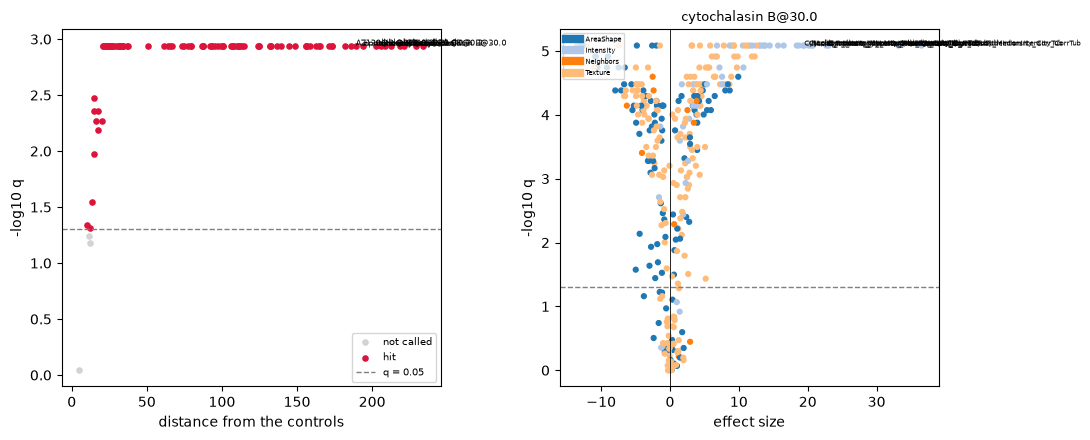

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
mt.pl.hits(adata, ax=axes[0])
mt.pl.feature_volcano(adata, group=hits.nlargest(1, "distance")["group"].iloc[0], ax=axes[1])
fig.tight_layout()
plt.show()

## Mechanism

In [6]:
treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
signatures = mt.tl.consensus(treated, method="median", min_replicates=1)
signatures = signatures[signatures.obs["Metadata_MOA"].notna().to_numpy()].copy()

mt.tl.nn_moa_classify(signatures, scheme="nsc")
mt.tl.enrich(signatures, by="group_by_channel", method="ulm", tmin=5)
mt.tl.rank_sets(signatures, groupby="Metadata_MOA")

{
    "treatments": signatures.n_obs,
    "mechanisms": int(signatures.obs["Metadata_MOA"].nunique()),
    "not-same-compound accuracy": round(signatures.uns["mantispy"]["moa"]["accuracy"], 3),
    "chance (largest class)": round(float(signatures.obs["Metadata_MOA"].value_counts(normalize=True).iloc[0]), 3),
}

{'treatments': 103,
 'mechanisms': 12,
 'not-same-compound accuracy': 0.777,
 'chance (largest class)': 0.136}

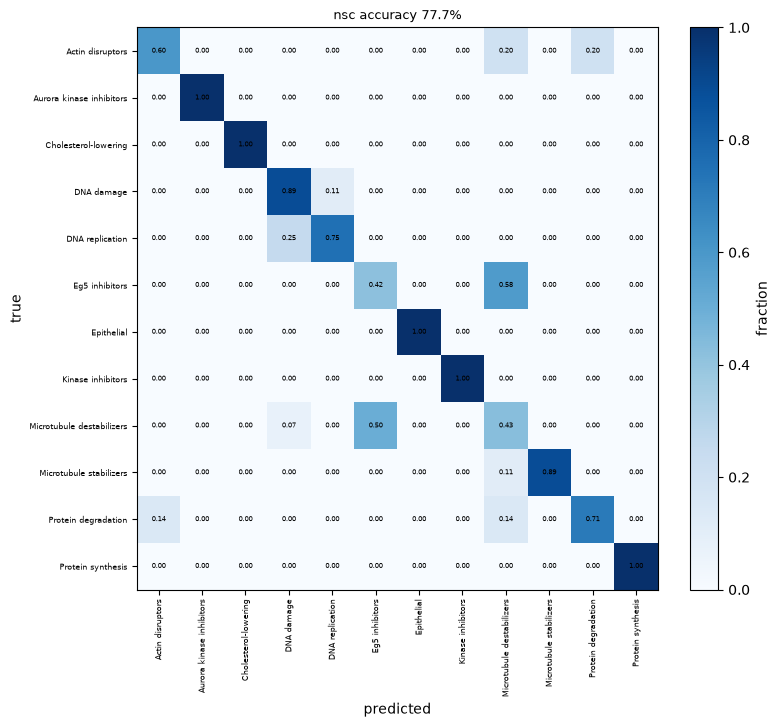

In [7]:
ax = mt.pl.moa_confusion(signatures)
plt.show()

## Everything is on the object

In [8]:
mt.io.write(signatures, "overview_signatures.h5ad")
reloaded = mt.io.read("overview_signatures.h5ad")

{
    "schema": reloaded.uns["mantispy"]["schema_version"],
    "resolution": reloaded.uns["mantispy"]["resolution"],
    "result tables": sorted(k for k in reloaded.uns["mantispy"] if k not in {"schema_version", "resolution", "params"}),
    "provenance": sorted(reloaded.uns["mantispy"]["params"]),
}

{'schema': '1.0',
 'resolution': 'perturbation',
 'result tables': ['consensus_weights', 'moa', 'moa_confusion', 'rank_sets'],
 'provenance': ['consensus', 'enrich', 'nn_moa_classify', 'rank_sets']}

Reading that file back gives the profiles, the mechanism assignments, the enrichment scores
and the parameters of every step.

## Where to go next

| page | question |
|---|---|
| [1. From CellProfiler to AnnData](01_from_cellprofiler_to_anndata.ipynb) | how do I get my data in, and what do the feature names mean? |
| [2. From cells to profiles](02_from_cells_to_profiles.ipynb) | QC, normalization, aggregation |
| [3. Trustworthy profiles](03_trustworthy_profiles.ipynb) | which features are worth keeping? |
| [4. Correcting and evaluating](04_correcting_and_evaluating.ipynb) | did my batch correction help, or hurt? |
| [5. Hits and effects](05_hits_and_effects.ipynb) | which perturbations had an effect, and what changed? |
| [6. Mechanism of action](06_mechanism_of_action.ipynb) | what does this compound do? |
| [7. Single-cell heterogeneity](07_single_cell_heterogeneity.ipynb) | what does a well median hide? |
| [8. Trustworthy features and design](08_trustworthy_features_and_design.ipynb) | which features can I trust, and how many replicates do I need? |
| [9. Scaling and laboratories](09_scaling_and_sites.ipynb) | data that does not fit, and data from eleven laboratories |
| [10. Differential features](10_differential_features.ipynb) | which features moved, and are the p-values reliable? |

The [API reference](../api.md) lists every function with what it stores, the data contract
and its stability guarantee, and the measured performance.